In [804]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.neighbors import LocalOutlierFactor

In [ ]:
# loading data
df = pd.read_csv('https://raw.githubusercontent.com/ARelaxedScholar/Assignment3RepositoryCSI4142/refs/heads/main/CAR-DETAILS-FROM-CAR-DEKHO.csv')

df.head(20)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000,25000,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014,240000,60000,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015,850000,25000,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017,365000,78000,CNG,Individual,Manual,First Owner


### Data Cleaning

a) Cleaning the data

- a. You have programmed in Assignment 2 some validity checks and imputation methods.
Reuse your methods here to clean your data.

We analyze the data directly to identify any strange values in numerical or categorical features.

In [764]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


There does not appear to be any null values in the data columns.

In [765]:
df["name"].count(), len(df["name"].unique())

(np.int64(4340), 1491)

In [766]:
df["name"].value_counts()

name
Maruti Swift Dzire VDI                          69
Maruti Alto 800 LXI                             59
Maruti Alto LXi                                 47
Hyundai EON Era Plus                            35
Maruti Alto LX                                  35
                                                ..
Maruti Swift LDI                                 1
Tata Nano XM                                     1
Mahindra Verito 1.5 D6 BSIII                     1
Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV     1
Hyundai i20 Magna 1.4 CRDi                       1
Name: count, Length: 1491, dtype: int64

In [767]:
df["owner"].value_counts()

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64

This hints at an ordinal encoding. A higher number would indicate a more worn or used car. This makes it appropriate to indicate a higher level with ordinal encoding.

In [768]:
df["seller_type"].value_counts()

seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

Based on google search, a "TrustMark" dealer is a certified pre-owned delearship. This is the website from which the dataset data is from:

https://www.cardekho.com/trustmark/index.html

It explains that a TrustMark car is just a previously owned car.

In [769]:
df["fuel"].value_counts()

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

CNG stands for Compressed Natural Gas (CNG) and LPG stands for Liquefied Petroleum Gas (LPG). Both are cleaner-burning alternatives to gasoline and diesel. CNG is mostly methane, and LPG mostly propane and butane.

In [770]:
df["km_driven"].max(), df["km_driven"].min()

(np.int64(806599), np.int64(1))

Checking for no insanely high values or impossibly low values (negative).

In [771]:
df["selling_price"].max(), df["selling_price"].min()

(np.int64(8900000), np.int64(20000))

The max value is likely 8,900,000 $Rupees. This puts us at around 130k CAD at current exchange rate. This is an appropriate value for a car, though expensive. The min value of 20,000 gives us around $200 CAD, probably for a in rather poor condition. 


In [772]:
df["year"].value_counts()

year
2017    466
2015    421
2012    415
2013    386
2014    367
2018    366
2016    357
2011    271
2010    234
2019    195
2009    193
2008    145
2007    134
2006    110
2005     85
2020     48
2004     42
2003     23
2002     21
2001     20
1998     12
2000     12
1999     10
1997      3
1996      2
1995      1
1992      1
Name: count, dtype: int64

There are no strange or impossible dates in the years.

Preparing the data for the column transforemr.

In [773]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [774]:
# preparing data types for column transformer

df["name"] = df["name"].astype("category")
df["year"] = df["year"].astype('int32')
df["selling_price"] = df["selling_price"].astype('int32')
df["km_driven"] = df["km_driven"].astype('int32')
df["fuel"] = df["fuel"].astype("category")
df["seller_type"] = df["seller_type"].astype("category")
df["transmission"] = df["transmission"].astype("category")
df["owner"] = df["owner"].astype("category")

### Local Outlier Detection



c) EDA and Outlier detection
- a. We explored in class different approaches for outlier detection, one of them being Local
Outlier Factor (LOF). Program such approach for outlier detection.
- b. As LOF is costly to use (if large dataset), first use EDA to visualize the data and find which
feature LOF should be used on. If there are no features with outliers in your dataset, then
purposely introduce some outliers for at least one feature so you can use LOF to detect
them.
- c. Decide what to do with outliers. Either remove them, or consider them as missing values
on which to apply imputation methods.

First, we perform some Exploratory Data Analysis on the data to visually identify outliers.

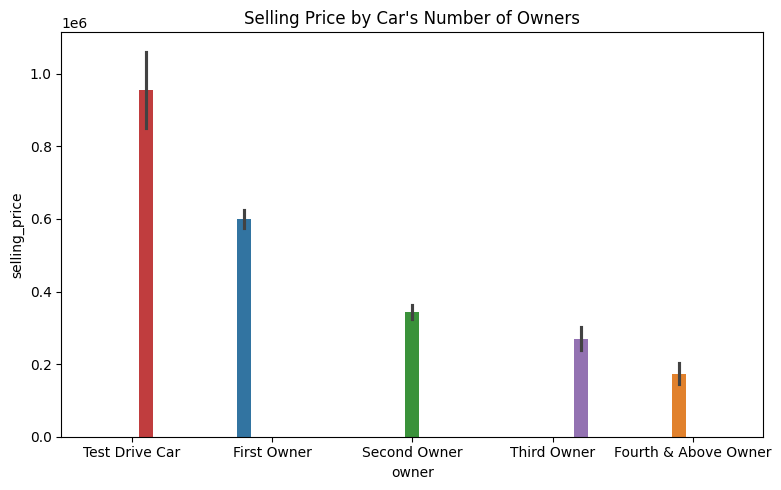

In [775]:
plt.figure(figsize=(8,5))
sns.barplot(
    df,
    x="owner",
    y="selling_price",
    width=0.5,order=["Test Drive Car", "First Owner", "Second Owner", "Third Owner", "Fourth & Above Owner"],
    hue="owner")
plt.title("Selling Price by Car's Number of Owners")
plt.tight_layout()

At first, there was the hypothesis that maybe 'Test Drive Car' was an outlier, given its high price and high ratio of "entrance by different people." Under this logic, it was assumed that it should be cheaper priced, not high priced as shown.

However, from further analysis, these data suggest that a 'Test Drive Car' is valued at a higher price because it has not been owned by anyone yet, regardless of the fact that it may have been entered by many more different people than the other classes. Since it's less "owned" than First Owner cars, it should be more expensive.

So as to align with the data, we will take in mind this specific order when defining an Ordinal Encoding for this feature.

Text(0.5, 1.0, 'Selling Price by Transmission Type')

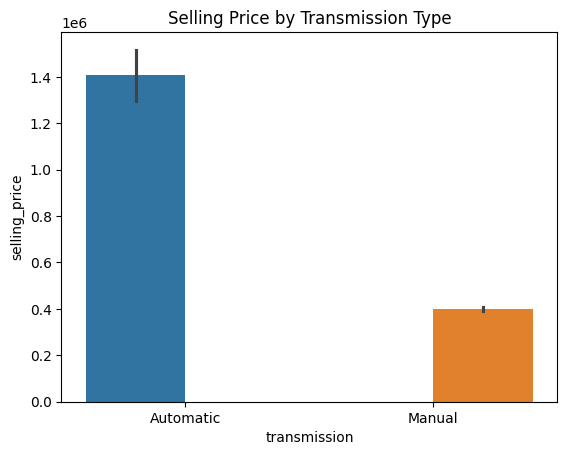

In [776]:
sns.barplot(df, x="transmission", y="selling_price", hue="transmission")
plt.title("Selling Price by Transmission Type")

There is a clear class imbalance here, however since we are not trying to predict any categorical variable we believe this should not affect the predictions much.

In the cells that follow, we play around with numerical variables that directly affect the selling price until we find a good range and combination.

Text(0.5, 1.0, 'Selling Price by Odometer Reading')

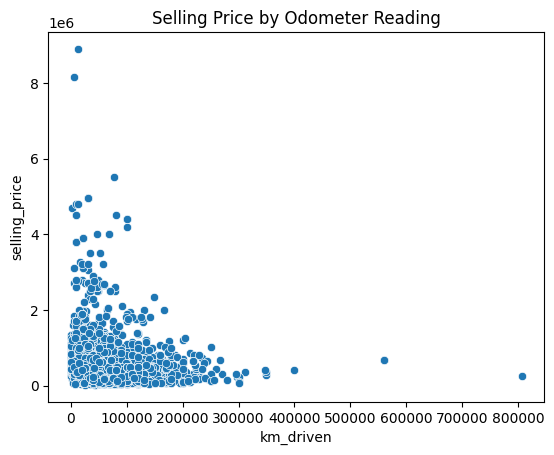

In [777]:
sns.scatterplot(df, x="km_driven", y="selling_price")
plt.title("Selling Price by Odometer Reading")

Text(0.5, 1.0, 'Selling Price by Odometer Reading <300k')

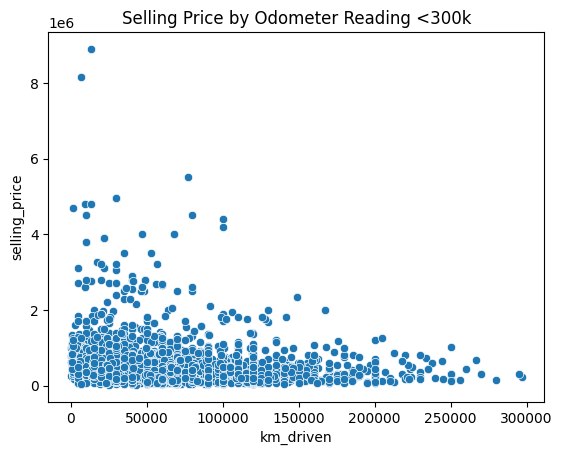

In [778]:
sns.scatterplot(df[df["km_driven"]<300000], x="km_driven", y="selling_price")
plt.title("Selling Price by Odometer Reading <300k")

Text(0.5, 1.0, 'Selling Price sub 5,000,000 Rupees by Odometer Reading <300k')

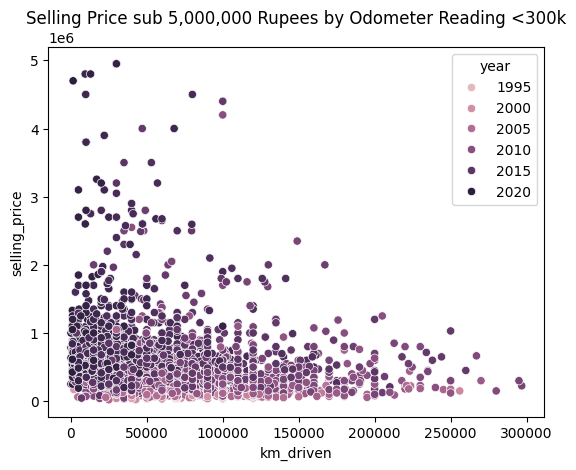

In [779]:
sns.scatterplot(
    df[(df["km_driven"]<300000)&(df["selling_price"]<5000000)],
    x="km_driven", 
    y="selling_price",
    hue="year")
plt.title("Selling Price sub 5,000,000 Rupees by Odometer Reading <300k")

5,000,000 equates to about 73k CAD at the current exchange rate. Maybe this would be a good cutoff for outliers.

Text(0.5, 1.0, 'Odometer Reading Datapoints (Strip Plot)')

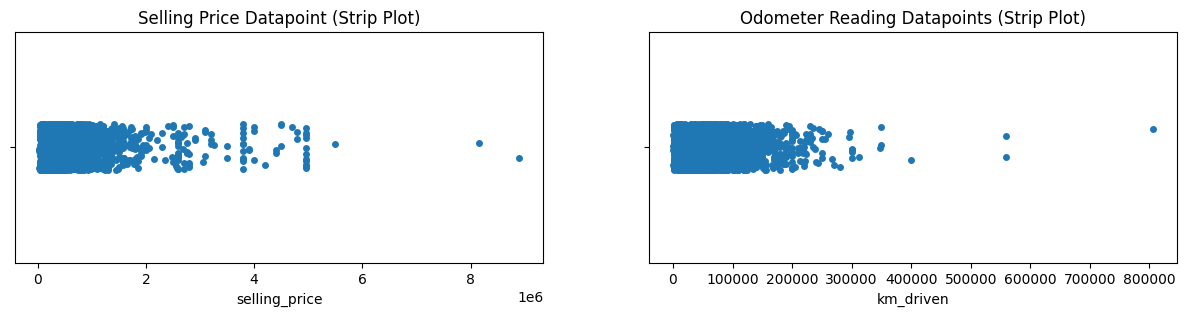

In [780]:
plt.figure(figsize=(15,3))

plt.subplot(1, 2, 1)
sns.stripplot(df, x="selling_price")
plt.title("Selling Price Datapoint (Strip Plot)")

plt.subplot(1, 2, 2)
sns.stripplot(df, x="km_driven")
plt.title("Odometer Reading Datapoints (Strip Plot)")

Although the points are rather clutterd near the lower end, we can see the obvious outliers in the respective numerical categories.

For the selling price, above 5,000,000 Rupees is unlikely to accurately represent the rest of the data.

For the kilometers driven, above 400k km contains outliers.

Text(0.5, 1.0, 'Countplot by Fuel Type')

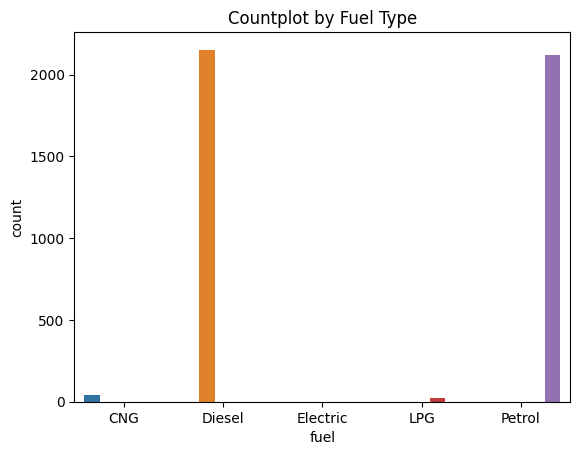

In [781]:
sns.countplot(df, x="fuel", hue="fuel")
plt.title("Countplot by Fuel Type")

We note that the CNG, LPG, and Electric categories are minisucule in comparison to the other two.

In [782]:
df["fuel"].value_counts()

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

Text(0.5, 1.0, 'Sale Price of Cars by Fuel Type OG (1992-2020)')

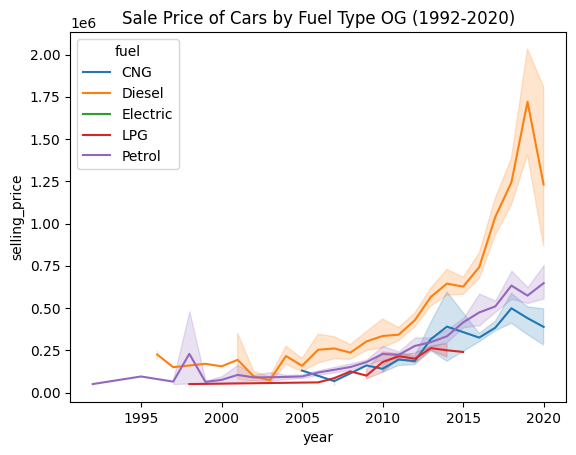

In [783]:
sns.lineplot(df, x="year", y="selling_price", hue="fuel")
max_year = df["year"].max()
min_year = df["year"].min()
plt.title(f"Sale Price of Cars by Fuel Type OG ({min_year}-{max_year})")

However, they tend to follow the same trend as the next two majority classes. As for Electric, it does not appear very much since there is only one count of it. We will merge all 3 categories together.

In [784]:
# making df copy for modified inline df
inlier_df = df.copy()

new_category = "CLE" # for CNG LPG and Electric
inlier_df["fuel"] = df["fuel"].apply(lambda x: "CLE" if x == "CNG" or x == "LPG" or  x== "Electric" else x)

Text(0.5, 1.0, 'Sale Price of Cars by Fuel Type CLE (1992-2020)')

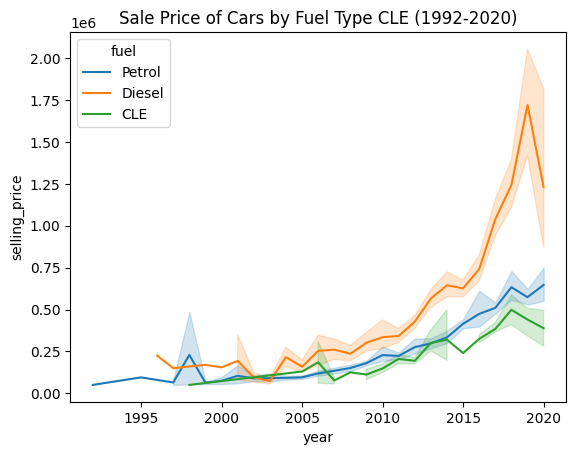

In [785]:
sns.lineplot(inlier_df, x="year", y="selling_price", hue="fuel")
max_year = df["year"].max()
min_year = df["year"].min()
plt.title(f"Sale Price of Cars by Fuel Type CLE ({min_year}-{max_year})")

Text(0.5, 1.0, 'Countplot by Seller Type')

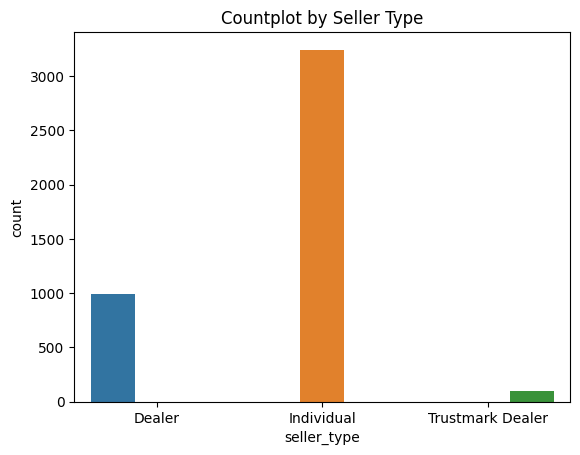

In [786]:
sns.countplot(df, x="seller_type", hue="seller_type")
plt.title("Countplot by Seller Type")

Text(0.5, 1.0, 'Sale Price of Cars between 1992-2020')

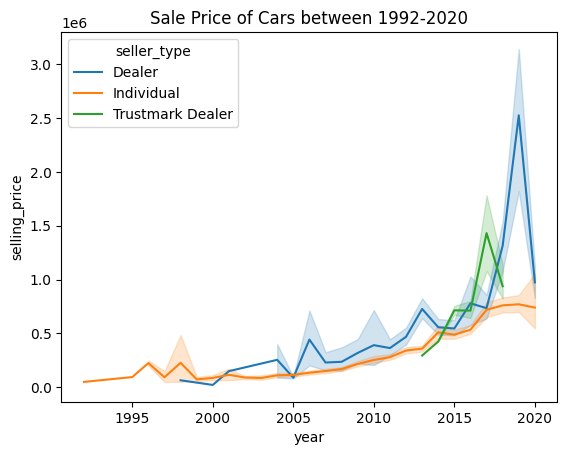

In [787]:
sns.lineplot(df, x="year", y="selling_price", hue="seller_type")
max_year = df["year"].max()
min_year = df["year"].min()
plt.title(f"Sale Price of Cars between {min_year}-{max_year}")

There 3 important things we notice from the graph above:
- Trustmark Dealer data is only listed for the ~2013-2017 years, with a spike in ~2016
- There is a spike in dealership sales around 2018-2019
- Both dealership and individual sales fall around 2020

In [788]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


We now perform outlier removal with the following columns:
- km_driven
- selling_price
- year

In [789]:
# Initialize and fit LOF
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.2)

# we only perform the oulier detection with km_driven, selling_price, and year
outlier_keep_column = inlier_df.drop(columns=["name", "fuel", "seller_type", "transmission", "owner"])

# Results: -1 indicates an outlier, 1 indicates inlier
outliers = clf.fit_predict(outlier_keep_column)

# df where inlier
inlier_df = inlier_df[outliers == 1]
df.count(), inlier_df.count()


(name             4340
 year             4340
 selling_price    4340
 km_driven        4340
 fuel             4340
 seller_type      4340
 transmission     4340
 owner            4340
 dtype: int64,
 name             3472
 year             3472
 selling_price    3472
 km_driven        3472
 fuel             3472
 seller_type      3472
 transmission     3472
 owner            3472
 dtype: int64)

We see some values have been removed. We now plot the data again to see if the outliers were removed as expected.

### Outlier Removal Check

Text(0.5, 1.0, 'Odometer Strip Plot (w/o Outlier)')

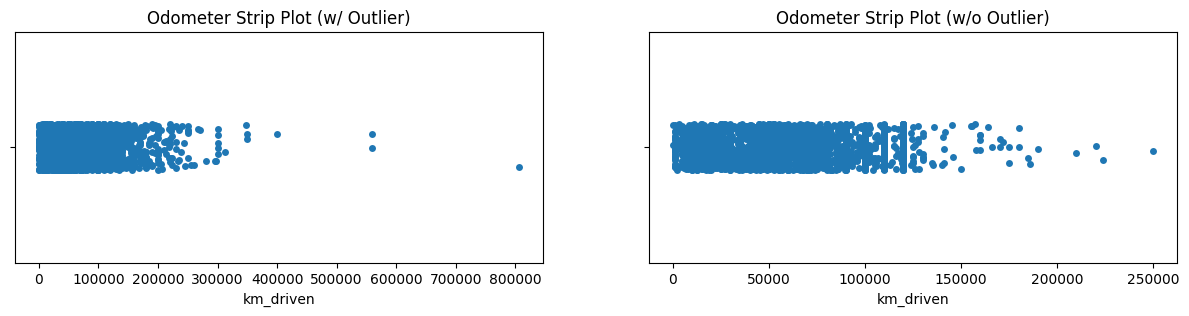

In [790]:
plt.figure(figsize=(15,3))

plt.subplot(1, 2, 1)
sns.stripplot(df, x="km_driven")
plt.title("Odometer Strip Plot (w/ Outlier)")

plt.subplot(1, 2, 2)
sns.stripplot(inlier_df, x="km_driven")
plt.title("Odometer Strip Plot (w/o Outlier)")

If you look at the range between the two graphs, we can see we have greatly reduced the outliers past 400k km. It may even have been a little aggresive, as it seems to have removed some of the 300k points too.

Text(0.5, 1.0, 'Selling Price Strip Plot (w/o Outlier)')

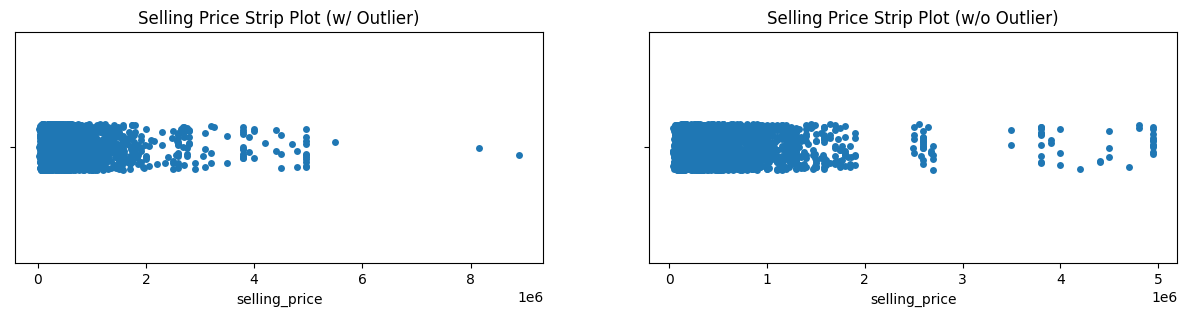

In [791]:
plt.figure(figsize=(15,3))

plt.subplot(1, 2, 1)
sns.stripplot(df, x="selling_price")
plt.title("Selling Price Strip Plot (w/ Outlier)")

plt.subplot(1, 2, 2)
sns.stripplot(inlier_df, x="selling_price")
plt.title("Selling Price Strip Plot (w/o Outlier)")

If you look at the range between the two graphs, we can see we have greatly reduced the outliers past 6,000,000 Rupees.

Text(0.5, 1.0, 'Odometer Strip Plot (w/o Outliers)')

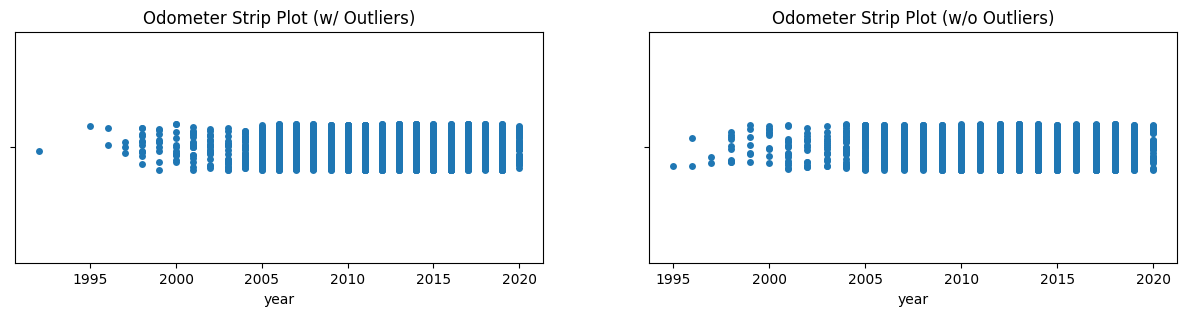

In [792]:
plt.figure(figsize=(15,3))

plt.subplot(1, 2, 1)
sns.stripplot(df, x="year")
plt.title("Odometer Strip Plot (w/ Outliers)")

plt.subplot(1, 2, 2)
sns.stripplot(inlier_df, x="year")
plt.title("Odometer Strip Plot (w/o Outliers)")

And we can see our 'year' feature has remained largely unchanged. It was used to identify the other outliers in km_driven and selling_price without being affected itself.

Preparing for teh colum tranosfmr.mm

In [793]:
# preparing data types for column transformer

inlier_df["name"] = inlier_df["name"].astype("category")
inlier_df["year"] = inlier_df["year"].astype('int32')
inlier_df["selling_price"] = inlier_df["selling_price"].astype('int32')
inlier_df["km_driven"] = inlier_df["km_driven"].astype('int32')
inlier_df["fuel"] = inlier_df["fuel"].astype("category")
inlier_df["seller_type"] = inlier_df["seller_type"].astype("category")
inlier_df["transmission"] = inlier_df["transmission"].astype("category")
inlier_df["owner"] = inlier_df["owner"].astype("category")

### Encoding + Linear Regression Task


b) Categorical feature encoding
a. Linear regression applies to numerical features. We have seen in class that one-hot
encoding can transform categorical features into numerical features. Apply such encoding

d) Predictive analysis: Linear regression
- a. Explore the LinearRegression method suggested in scikit-learn (or other packages). scikit-
learn also contains Ridge, Lasso and ElasticNet regressions if you want to explore those
(optional).

In [794]:
### Linear Regression Task

# defining ordinal column order
ordinal_columns = ["owner"]
# order is based on EDA done earlier, makese sense
ordinal_order = ["Test Drive Car", "First Owner", "Second Owner", "Third Owner", "Fourth & Above Owner"]

# Feature Transformer to make features usable in Linear regression
preprocessor = ColumnTransformer(
    transformers=[
        # One-hot encoding for categorical variables
        ("categorical", OneHotEncoder(handle_unknown='ignore'), make_column_selector(dtype_include="category")),
        # Ordinal encoding for the 'owner' column
        ("ordinal", OrdinalEncoder(categories=[ordinal_order]), ordinal_columns)
    ],
    # for numerical features "year", "selling_price", "km_driven"
    remainder=StandardScaler(),
)

# pipeline
    # fits and applies 'preprocessor' transformations
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())])


### Feature Aggregation

e) Feature Engineering
- a. Program a feature aggregator to create 2 additional features. We will explore aggregation
during March 11th lecture, but you can go ahead earlier and program something simple
(e.g. adding two features). Think of interesting ways to combine the features based on the
dataset and what could make sense. The purpose of aggregation is to create new features
from the ones you have.

We make two (kinda 3) new features:
- KM Driven per Year
- Car Brand
- Car Name (w/o Brand)

In [795]:
# we make a df copy
aggregated_df = inlier_df.copy()

# we will create a category that is the average annual kilometer
    # we assume the current year is the max year in the dataset
    # we assume the "year" column refers to the model year of the car
current_year = inlier_df["year"].max()

# calculating years passed since manufcature
diff = current_year - inlier_df["year"]
# If diff is 0, use 1, else use diff
years_elapsed = np.where(diff == 0, 1, diff)

# km per year feature
aggregated_df["km_per_year"] = (inlier_df["km_driven"] / years_elapsed).round(2)



# we will also create a new feature that extracts the car brand from the name
    # it is not pefect, but we will simply assume the first word in the string to be the brand
aggregated_df["brand"] = inlier_df["name"].apply(lambda x: x.split(' ')[0])
# collects the rest of string without the brand (basically the car name)
    # splits by ' ' then grabs index 1 to end.
    # then needs to join back as a single string
aggregated_df["name"] = inlier_df["name"].apply(lambda x: " ".join(x.split(' ')[1:]))



This is the resulting aggregated-feature dataset.

In [796]:
# preparing data types for column transformer

aggregated_df["brand"] = aggregated_df["brand"].astype("category")
aggregated_df["name"] = aggregated_df["name"].astype("category")
aggregated_df["year"] = aggregated_df["year"].astype('int32')
aggregated_df["selling_price"] = aggregated_df["selling_price"].astype('int32')
aggregated_df["km_per_year"] = aggregated_df["km_per_year"].astype('float')
aggregated_df["km_driven"] = aggregated_df["km_driven"].astype('int32')
aggregated_df["fuel"] = aggregated_df["fuel"].astype("category")
aggregated_df["seller_type"] = aggregated_df["seller_type"].astype("category")
aggregated_df["transmission"] = aggregated_df["transmission"].astype("category")
aggregated_df["owner"] = aggregated_df["owner"].astype("category")

### Empirical Study

f) Empirical study
- a. Split your data into 3 subsets for train, validation and test sets.**
- b. Decide on some evaluation metric(s) (MSE, LMSE, R2). Choose at least one.
- c. As baseline, use the linear regression with baseline settings, without outlier removal and
without feature aggregation. Using your chosen metric(s), evaluate on the validation set
using a 4-fold cross-validation.
- d. Try different (at least 3) system configurations (e.g. with/without dealing with outliers,
with/without feature aggregation). Using your chosen metric(s), evaluate the different
system configurations on the validation set using a 4-fold cross-validation. Based on those
experiments, you will choose the best configuration.
- e. Retrain your best configuration on train and validation combined and use the Test Set to
perform your final evaluation. This is to simulate a future test at a client’s site. The Test Set
should NOT have been used before this final evaluation.

The three datasets we have are as follows:
- `df` (regular unchanged)
- `inlier_df` (df with oulier remove)
- `aggregated_df` (aggregated feature + outlier removed)

we now perform the cross-validation:

In [797]:
# list with collected pokémon
dfs = [
    {"name":"reg", "dataframe": df},
    {"name":"outlier_removed","dataframe":inlier_df},
    {"name":"outlier_aggregated","dataframe":aggregated_df}]

# predicting feature
pred_feature = "selling_price"

# iterate through all version and do cross-validation
for item in dfs:
    # dataframe
    a_df = item["dataframe"]

    # X dataframe
    X = a_df.drop(columns=pred_feature)

    # saving prediction variable
    y = a_df["selling_price"].values.reshape(-1, 1)

    # split into train, test, validation

    # split test set
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # saving for retraining
    item["train_sets"] = (X_train_full, y_train_full)
    item["test_sets"] = (X_test, y_test)

    # split validation
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

    item["scores"] = cross_validate(model_pipeline, X, y, cv=4, return_estimator=True, scoring=['r2', 'neg_mean_squared_error'])

We now get the score values for the cross validation.

In [798]:
dfs[0]["scores"].keys()

dict_keys(['fit_time', 'score_time', 'estimator', 'test_r2', 'test_neg_mean_squared_error'])

In [799]:
for a_df in dfs:
    header = "#"*23 + f" Scores for model '{a_df["name"]}' " + "#"*23
    print(header)
    print("R2 Scores:")
    print(a_df["scores"]["test_r2"])
    print()
    print("Negative Mean Square Error Scores:")
    print(a_df["scores"]["test_neg_mean_squared_error"])
    print()
    print("#"*len(header))
    print()

####################### Scores for model 'reg' #######################
R2 Scores:
[0.79028723 0.77815962 0.90486877 0.56346015]

Negative Mean Square Error Scores:
[-1.12550621e+11 -4.38350887e+10 -2.69097719e+10 -1.35050898e+11]

######################################################################

####################### Scores for model 'outlier_removed' #######################
R2 Scores:
[0.8636488  0.7867722  0.91481823 0.60262752]

Negative Mean Square Error Scores:
[-7.07724902e+10 -4.28557400e+10 -2.53205444e+10 -8.43844328e+10]

##################################################################################

####################### Scores for model 'outlier_aggregated' #######################
R2 Scores:
[0.92492828 0.85836431 0.90003749 0.71553087]

Negative Mean Square Error Scores:
[-3.89656457e+10 -2.84667485e+10 -2.97141625e+10 -6.04087279e+10]

#####################################################################################



The high R2 scores show that our model is following the general pattern of the dataset. However, the rather poor Mean Square Error tells us that it is rarely close to the real datapoints. This comes as no surprise as we could see from the data during EDA that most data was clustered in specific regions.

Further, we could see from a few figures that depending on the feature we were comparing it too, the data was not exaclty linear either. There was unequal variance throughou the datapoints while also curving slightly. Overall, the model seems to be doing as well as we would expect given the Linear Regression method we are limited to.

In general, however, we can see the `aggregated_df` model performed with a higher r2 value. In fact, we can see the `reg` model achieves only slighlty better MSE at the cost of reduced r2.


In [800]:
# selecting best split from cross validation for aggregated_df
X_train_final, y_train_final = dfs[2]["train_sets"]
X_test_final, y_test_final = dfs[2]["test_sets"]

# fitting model
model_pipeline.fit(X_train_final, y_train_final)

# predicting
final_predictions = model_pipeline.predict(X_test_final)

r2 = r2_score(y_test_final, final_predictions)
print(f"R² score: {r2}")

mse = mean_squared_error(y_test_final, final_predictions)
print(f"The Mean Squared Error is: {mse}")



R² score: 0.8323308558959235
The Mean Squared Error is: 46324647946.0605


Our final R2 predictions scores is as shown above.